# Datathon Passos Mágicos — EDA e Análise de Negócio (2022–2024)
**Pós-graduação em Data Analytics — FIAP Postech — Fase 5**

Responde as **11 perguntas de negócio** do desafio com base no painel longitudinal
tratado na etapa anterior. Cada seção corresponde a uma pergunta do enunciado.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo geral
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

df = pd.read_csv('/mnt/user-data/outputs/painel_pede_tratado.csv')

# Padroniza coluna Pedra (Agata -> Ágata)
df['Pedra'] = df['Pedra'].replace({'Agata': 'Ágata', 'INCLUIR': None})

ORDEM_PEDRA = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
INDICADORES  = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'IPP']
ANOS         = [2022, 2023, 2024]

print(f'Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(df['Ano_Referencia'].value_counts().sort_index())


Base carregada: 3030 linhas x 38 colunas
Ano_Referencia
2022     860
2023    1014
2024    1156
Name: count, dtype: int64


## Pergunta 1 — Adequação ao Nível (IAN)
*Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo do ano?*

O **IAN** assume três valores: **2,5** (severo), **5,0** (moderado) e **10,0** (adequado).


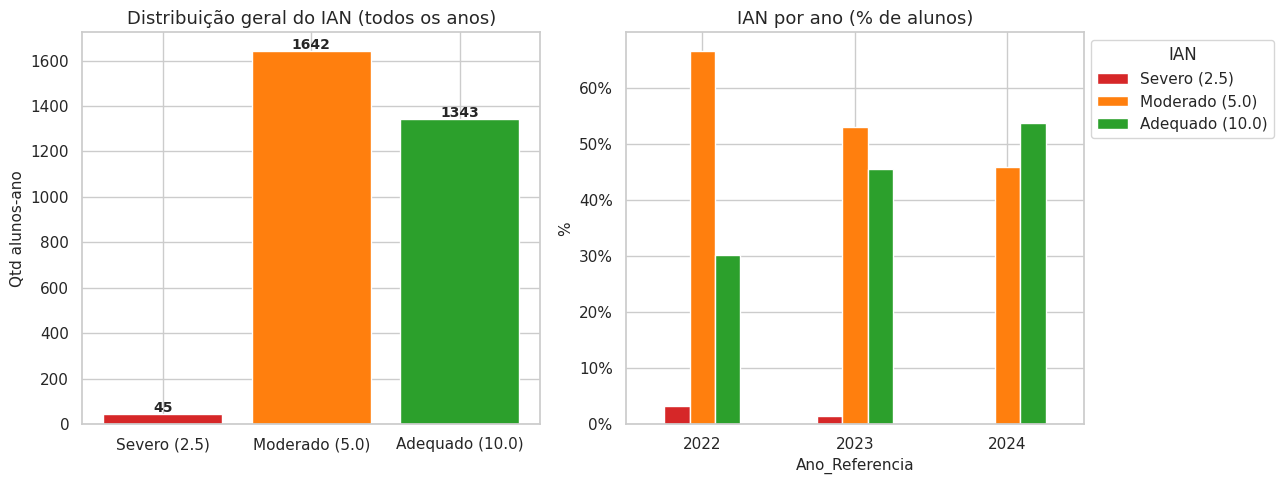

IAN_Cat         Adequado (10.0)  Moderado (5.0)  Severo (2.5)  \
Ano_Referencia                                                  
2022                        259             573            28   
2023                        462             538            14   
2024                        622             531             3   

IAN_Cat         % Defasagem (Sev+Mod)  
Ano_Referencia                         
2022                             69.9  
2023                             54.4  
2024                             46.2  


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IAN: distribuição geral por categoria
def categoriza_ian(v):
    if pd.isna(v): return None
    if v <= 2.5:   return 'Severo (2.5)'
    if v <= 5.0:   return 'Moderado (5.0)'
    return 'Adequado (10.0)'

df['IAN_Cat'] = df['IAN'].apply(categoriza_ian)
ordem_ian = ['Severo (2.5)', 'Moderado (5.0)', 'Adequado (10.0)']
cores_ian  = ['#d62728', '#ff7f0e', '#2ca02c']

contagem = df['IAN_Cat'].value_counts().reindex(ordem_ian)
axes[0].bar(contagem.index, contagem.values, color=cores_ian)
axes[0].set_title('Distribuição geral do IAN (todos os anos)')
axes[0].set_ylabel('Qtd alunos-ano')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10, fontweight='bold')

# IAN: evolução % por ano
ian_ano = (df.groupby('Ano_Referencia')['IAN_Cat']
             .value_counts(normalize=True)
             .mul(100).unstack().reindex(columns=ordem_ian))
ian_ano.plot(kind='bar', ax=axes[1], color=cores_ian, rot=0)
axes[1].set_title('IAN por ano (% de alunos)')
axes[1].set_ylabel('%')
axes[1].legend(title='IAN', bbox_to_anchor=(1, 1))
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p1_ian.png', bbox_inches='tight')
plt.show()

# Tabela resumo
resumo = df.groupby('Ano_Referencia')['IAN_Cat'].value_counts().unstack(fill_value=0)
resumo['% Defasagem (Sev+Mod)'] = (
    (resumo.get('Severo (2.5)', 0) + resumo.get('Moderado (5.0)', 0))
    / resumo.sum(axis=1) * 100
).round(1)
print(resumo)


## Pergunta 2 — Desempenho Acadêmico (IDA)
*O IDA médio está melhorando, estagnado ou caindo ao longo das fases e anos?*


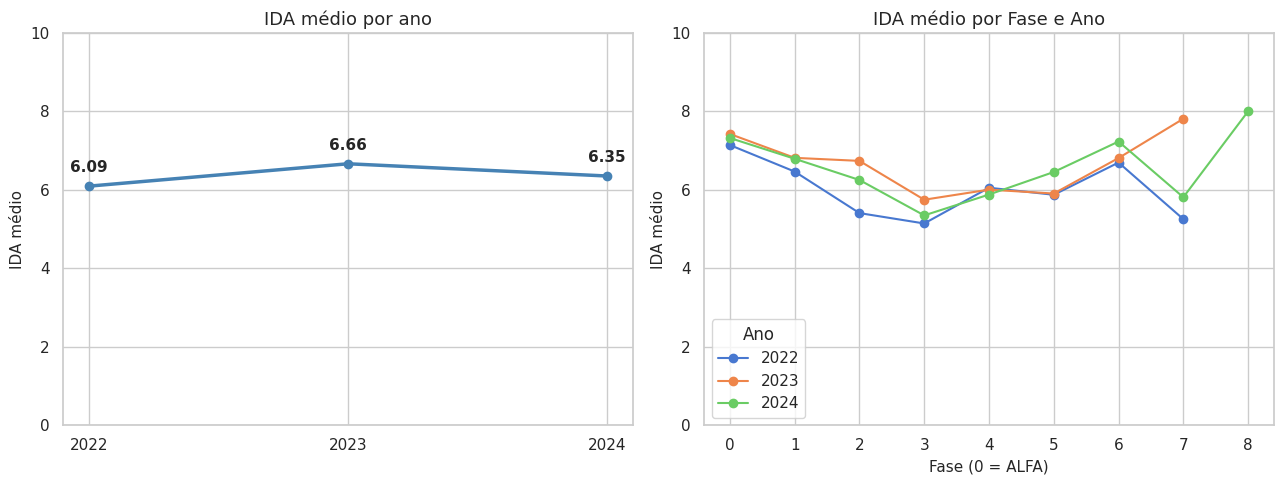

                IDA Médio
Ano_Referencia           
2022             6.092907
2023             6.663394
2024             6.351422


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IDA médio por ano
ida_ano = df.groupby('Ano_Referencia')['IDA'].mean()
axes[0].plot(ida_ano.index, ida_ano.values, marker='o', linewidth=2.5, color='steelblue')
for x, y in zip(ida_ano.index, ida_ano.values):
    axes[0].annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('IDA médio por ano')
axes[0].set_ylabel('IDA médio')
axes[0].set_xticks(ANOS)
axes[0].set_ylim(0, 10)

# IDA médio por Fase e Ano
ida_fase = (df[df['Fase_Num'].between(0, 8)]
              .groupby(['Fase_Num', 'Ano_Referencia'])['IDA'].mean().unstack())
ida_fase.plot(ax=axes[1], marker='o')
axes[1].set_title('IDA médio por Fase e Ano')
axes[1].set_xlabel('Fase (0 = ALFA)')
axes[1].set_ylabel('IDA médio')
axes[1].legend(title='Ano')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p2_ida.png', bbox_inches='tight')
plt.show()

print(ida_ano.rename('IDA Médio').to_frame())


## Pergunta 3 — Engajamento (IEG)
*O IEG tem relação direta com o IDA e o IPV?*


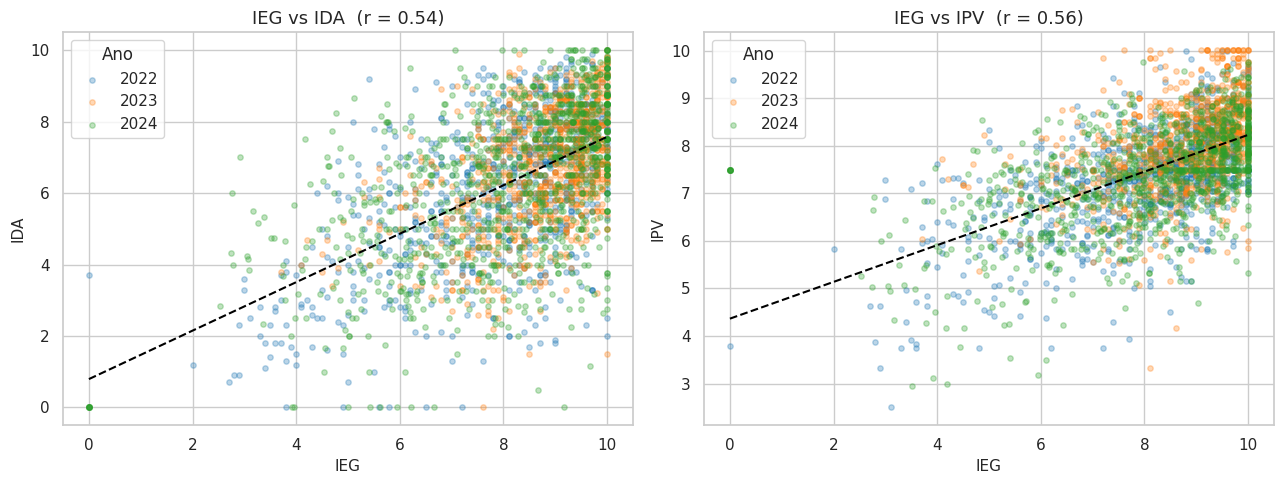

Correlações IEG, IDA, IPV:
       IEG    IDA    IPV
IEG  1.000  0.539  0.558
IDA  0.539  1.000  0.557
IPV  0.558  0.557  1.000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter IEG x IDA
df_valido = df[['IEG','IDA','IPV','Ano_Referencia']].dropna()
cores_ano = {2022:'#1f77b4', 2023:'#ff7f0e', 2024:'#2ca02c'}
for ano, grp in df_valido.groupby('Ano_Referencia'):
    axes[0].scatter(grp['IEG'], grp['IDA'], alpha=0.3, s=15,
                    color=cores_ano[ano], label=str(ano))
m, b = np.polyfit(df_valido['IEG'], df_valido['IDA'], 1)
x_line = np.linspace(df_valido['IEG'].min(), df_valido['IEG'].max(), 100)
axes[0].plot(x_line, m*x_line+b, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title(f'IEG vs IDA  (r = {df_valido["IEG"].corr(df_valido["IDA"]):.2f})')
axes[0].set_xlabel('IEG'); axes[0].set_ylabel('IDA')
axes[0].legend(title='Ano')

# Scatter IEG x IPV
for ano, grp in df_valido.groupby('Ano_Referencia'):
    axes[1].scatter(grp['IEG'], grp['IPV'], alpha=0.3, s=15,
                    color=cores_ano[ano], label=str(ano))
m2, b2 = np.polyfit(df_valido['IEG'], df_valido['IPV'], 1)
axes[1].plot(x_line, m2*x_line+b2, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title(f'IEG vs IPV  (r = {df_valido["IEG"].corr(df_valido["IPV"]):.2f})')
axes[1].set_xlabel('IEG'); axes[1].set_ylabel('IPV')
axes[1].legend(title='Ano')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p3_ieg.png', bbox_inches='tight')
plt.show()

corrs = df[['IEG','IDA','IPV']].corr()
print('Correlações IEG, IDA, IPV:')
print(corrs.round(3))


## Pergunta 4 — Autoavaliação (IAA)
*As percepções dos alunos sobre si mesmos (IAA) são coerentes com o IDA e o IEG?*


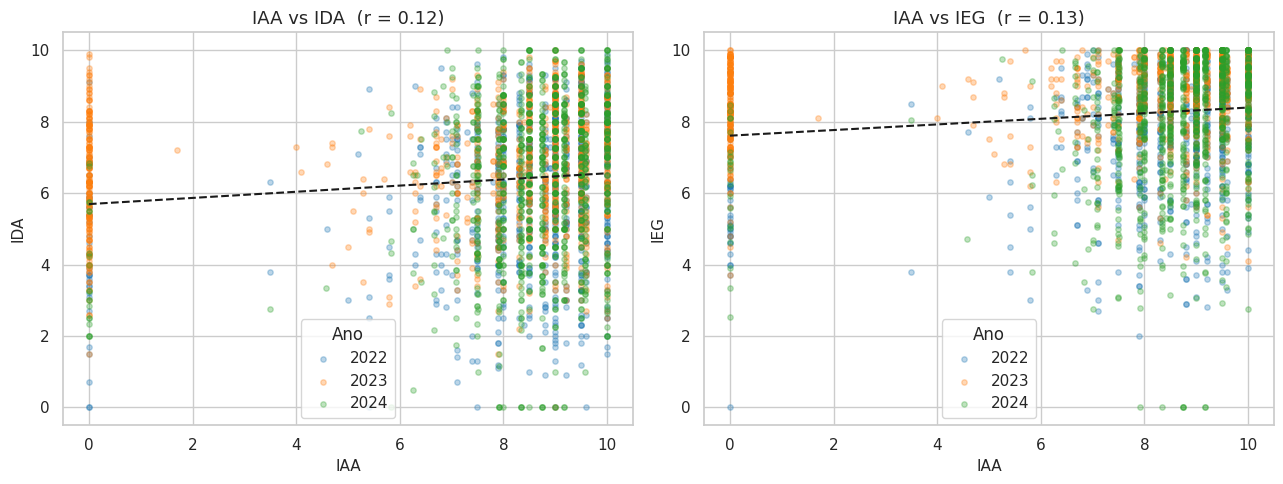

Correlações IAA vs demais indicadores:
IAA    1.000
IDA    0.115
IEG    0.133
IPS    0.157
IPV    0.063
Name: IAA, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_iaa = df[['IAA','IDA','IEG','Ano_Referencia']].dropna()

# IAA x IDA
for ano, grp in df_iaa.groupby('Ano_Referencia'):
    axes[0].scatter(grp['IAA'], grp['IDA'], alpha=0.3, s=15,
                    color=cores_ano[ano], label=str(ano))
m, b = np.polyfit(df_iaa['IAA'], df_iaa['IDA'], 1)
x_l = np.linspace(df_iaa['IAA'].min(), df_iaa['IAA'].max(), 100)
axes[0].plot(x_l, m*x_l+b, 'k--', linewidth=1.5)
axes[0].set_title(f'IAA vs IDA  (r = {df_iaa["IAA"].corr(df_iaa["IDA"]):.2f})')
axes[0].set_xlabel('IAA'); axes[0].set_ylabel('IDA')
axes[0].legend(title='Ano')

# IAA x IEG
for ano, grp in df_iaa.groupby('Ano_Referencia'):
    axes[1].scatter(grp['IAA'], grp['IEG'], alpha=0.3, s=15,
                    color=cores_ano[ano], label=str(ano))
m2, b2 = np.polyfit(df_iaa['IAA'], df_iaa['IEG'], 1)
axes[1].plot(x_l, m2*x_l+b2, 'k--', linewidth=1.5)
axes[1].set_title(f'IAA vs IEG  (r = {df_iaa["IAA"].corr(df_iaa["IEG"]):.2f})')
axes[1].set_xlabel('IAA'); axes[1].set_ylabel('IEG')
axes[1].legend(title='Ano')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p4_iaa.png', bbox_inches='tight')
plt.show()

print('Correlações IAA vs demais indicadores:')
print(df[['IAA','IDA','IEG','IPS','IPV']].corr()['IAA'].round(3))


## Pergunta 5 — Aspectos Psicossociais (IPS)
*Há padrões de IPS que antecedem quedas de desempenho ou engajamento?*


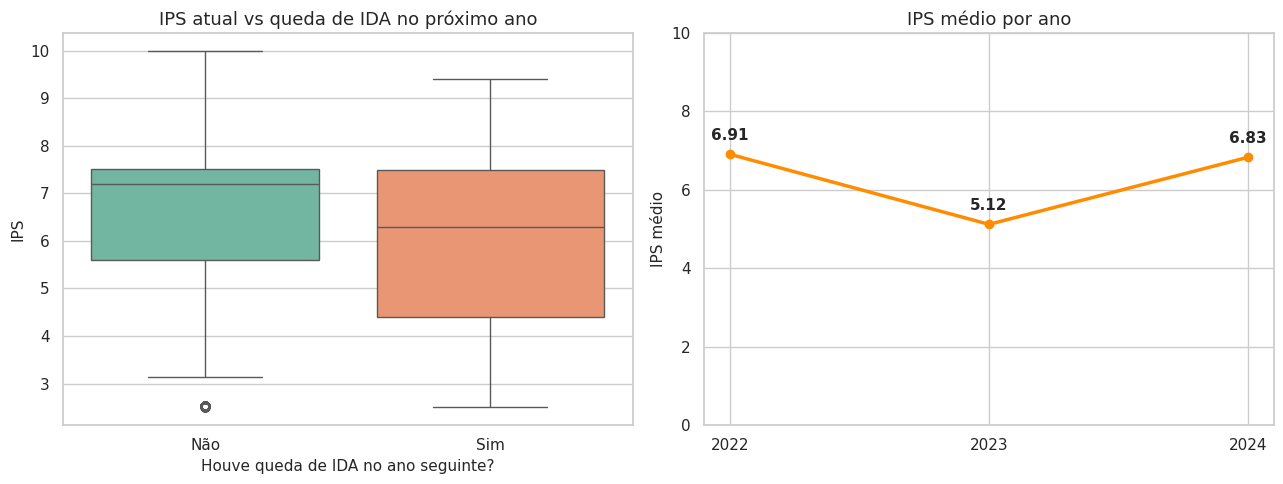

IPS médio por grupo (queda de IDA no ano seguinte):
Queda IDA
Não    6.289
Sim    5.873
Name: IPS, dtype: float64


In [6]:
# Alunos que aparecem em 2+ anos: verificar se baixo IPS precede queda de IDA
multi = df[df['RA'].map(df.groupby('RA').size()) > 1].copy()
multi = multi.sort_values(['RA','Ano_Referencia'])
multi['IDA_prox'] = multi.groupby('RA')['IDA'].shift(-1)
multi['queda_IDA'] = (multi['IDA_prox'] < multi['IDA']).astype(float)
multi_valido = multi[multi['queda_IDA'].notna() & multi['IPS'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot IPS x queda de IDA
multi_valido['Queda IDA'] = multi_valido['queda_IDA'].map({1.0: 'Sim', 0.0: 'Não'})
sns.boxplot(data=multi_valido, x='Queda IDA', y='IPS', palette='Set2', ax=axes[0])
axes[0].set_title('IPS atual vs queda de IDA no próximo ano')
axes[0].set_xlabel('Houve queda de IDA no ano seguinte?')
axes[0].set_ylabel('IPS')

# IPS médio por ano
ips_ano = df.groupby('Ano_Referencia')['IPS'].mean()
axes[1].plot(ips_ano.index, ips_ano.values, marker='o', linewidth=2.5, color='darkorange')
for x, y in zip(ips_ano.index, ips_ano.values):
    axes[1].annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('IPS médio por ano')
axes[1].set_ylabel('IPS médio')
axes[1].set_xticks(ANOS)
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p5_ips.png', bbox_inches='tight')
plt.show()

media_ips = multi_valido.groupby('Queda IDA')['IPS'].mean()
print('IPS médio por grupo (queda de IDA no ano seguinte):')
print(media_ips.round(3))


## Pergunta 6 — Aspectos Psicopedagógicos (IPP)
*As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem do IAN?*

> **Atenção:** IPP só está disponível a partir de 2023. A análise cobre 2023–2024.


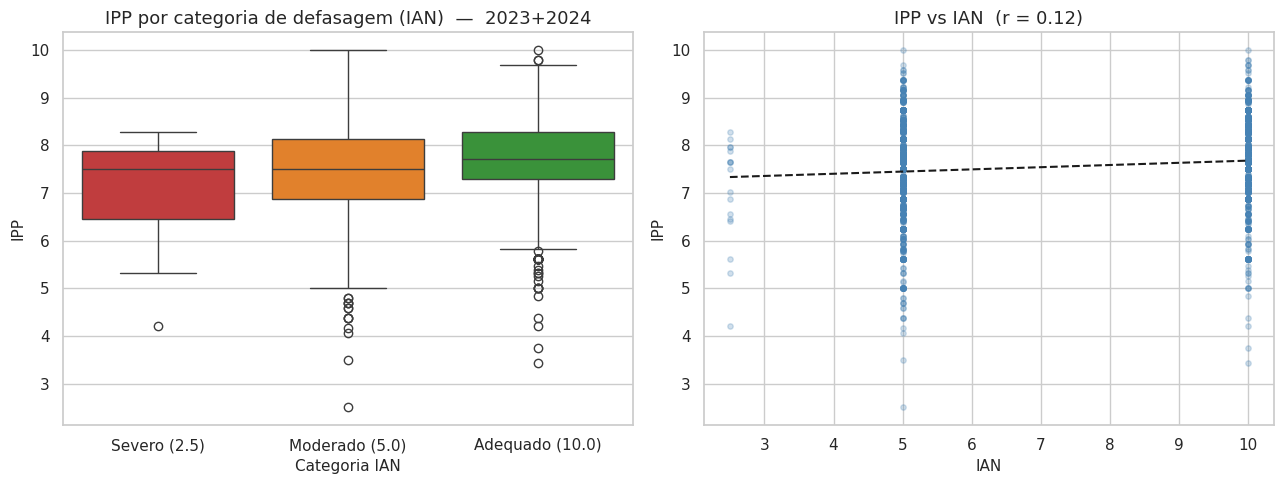

IPP médio por categoria de IAN:
IAN_Cat
Severo (2.5)       7.010
Moderado (5.0)     7.459
Adequado (10.0)    7.678
Name: IPP, dtype: float64


In [7]:
df_ipp = df[df['IPP'].notna() & df['Ano_Referencia'].isin([2023,2024])].copy()
df_ipp['IAN_Cat'] = df_ipp['IAN'].apply(categoriza_ian)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IPP por categoria de IAN
sns.boxplot(data=df_ipp, x='IAN_Cat', y='IPP',
            order=ordem_ian, palette=['#d62728','#ff7f0e','#2ca02c'], ax=axes[0])
axes[0].set_title('IPP por categoria de defasagem (IAN)  —  2023+2024')
axes[0].set_xlabel('Categoria IAN')
axes[0].set_ylabel('IPP')

# Scatter IPP x IAN
axes[1].scatter(df_ipp['IAN'], df_ipp['IPP'], alpha=0.25, s=15, color='steelblue')
m, b = np.polyfit(df_ipp['IAN'].dropna(), df_ipp['IPP'].dropna(), 1)
x_l = np.linspace(df_ipp['IAN'].min(), df_ipp['IAN'].max(), 100)
axes[1].plot(x_l, m*x_l+b, 'k--', linewidth=1.5)
axes[1].set_title(f'IPP vs IAN  (r = {df_ipp["IAN"].corr(df_ipp["IPP"]):.2f})')
axes[1].set_xlabel('IAN'); axes[1].set_ylabel('IPP')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p6_ipp.png', bbox_inches='tight')
plt.show()

print('IPP médio por categoria de IAN:')
print(df_ipp.groupby('IAN_Cat')['IPP'].mean().reindex(ordem_ian).round(3))


## Pergunta 7 — Ponto de Virada (IPV)
*Quais comportamentos acadêmicos, emocionais ou de engajamento mais influenciam o IPV?*

> O campo `Atingiu_Ponto_Virada` (booleano) só tem dado completo em 2022.
> Para os demais anos, usamos o **valor numérico do IPV** como proxy.


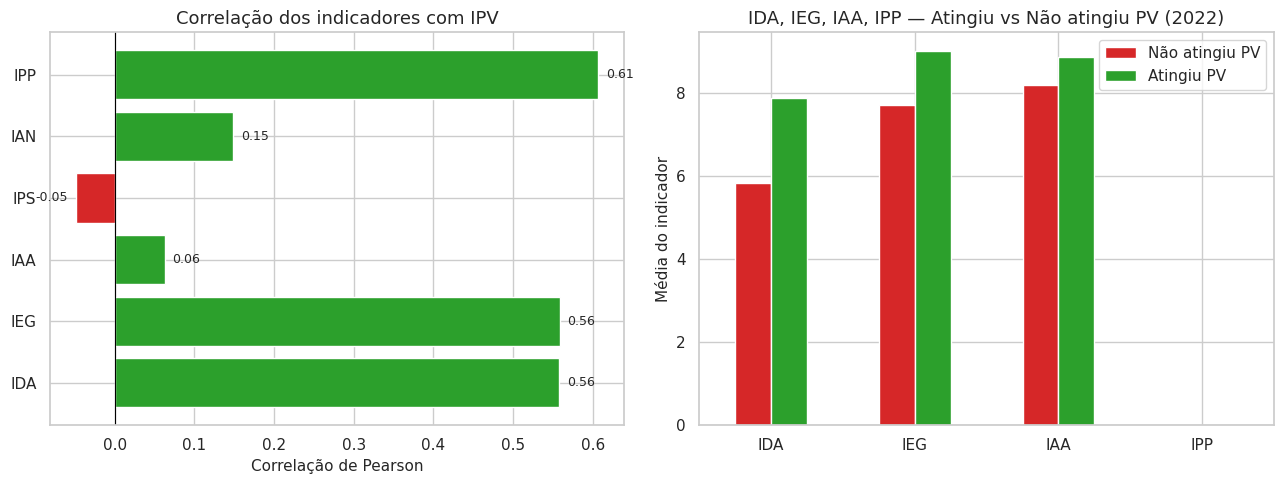

Médias por grupo PV (2022):
                  IDA    IEG    IAA  IPP
Não atingiu PV  5.824  7.722  8.185  NaN
Atingiu PV      7.869  9.012  8.867  NaN


In [8]:
# Correlações com IPV
corr_ipv = df[['IPV','IDA','IEG','IAA','IPS','IAN','IPP']].corr()['IPV'].drop('IPV')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot de correlações
cores_corr = ['#2ca02c' if v >= 0 else '#d62728' for v in corr_ipv.values]
axes[0].barh(corr_ipv.index, corr_ipv.values, color=cores_corr)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação dos indicadores com IPV')
axes[0].set_xlabel('Correlação de Pearson')
for i, (v, nome) in enumerate(zip(corr_ipv.values, corr_ipv.index)):
    axes[0].text(v + 0.01 if v >= 0 else v - 0.01, i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# PV real em 2022: IDA e IEG por grupo
df22 = df[df['Ano_Referencia']==2022].copy()
df22['PV'] = df22['Atingiu_Ponto_Virada'].map({'Sim':1, 'Não':0})
df22_valido = df22[df22['PV'].notna()]
medias_pv = df22_valido.groupby('PV')[['IDA','IEG','IAA','IPP']].mean()
medias_pv.index = ['Não atingiu PV','Atingiu PV']
medias_pv.T.plot(kind='bar', ax=axes[1], color=['#d62728','#2ca02c'], rot=0)
axes[1].set_title('IDA, IEG, IAA, IPP — Atingiu vs Não atingiu PV (2022)')
axes[1].set_ylabel('Média do indicador')
axes[1].legend()

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p7_ipv.png', bbox_inches='tight')
plt.show()

print('Médias por grupo PV (2022):')
print(medias_pv.round(3))


## Pergunta 8 — Multidimensionalidade dos Indicadores
*Quais combinações de indicadores elevam mais o INDE?*


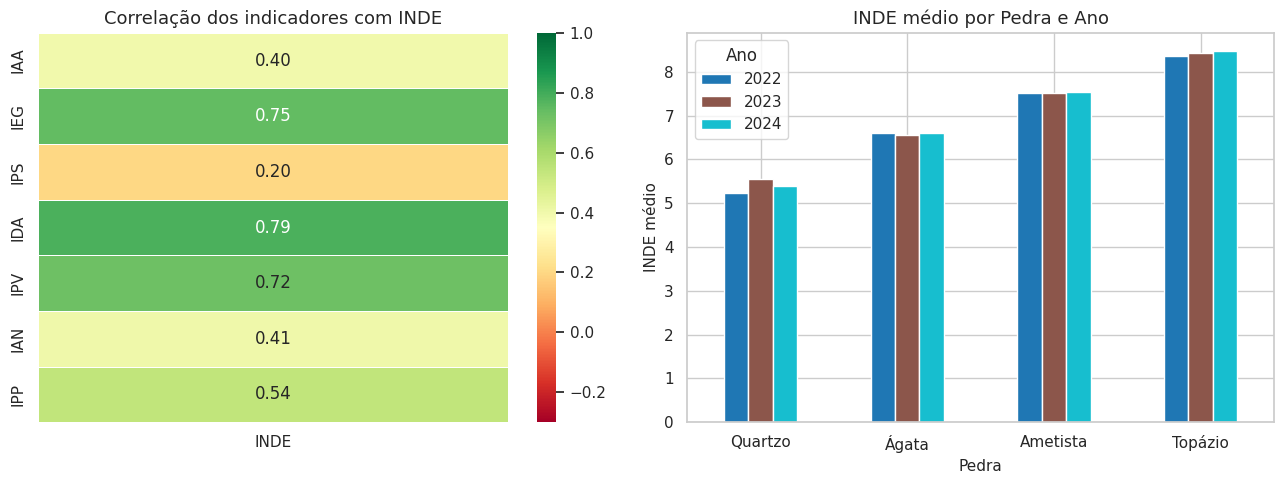

Correlação com INDE (rank):
      INDE
IDA  0.785
IEG  0.745
IPV  0.721
IPP  0.540
IAN  0.405
IAA  0.397
IPS  0.200


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap de correlações com INDE
corr_inde = df[['INDE'] + INDICADORES].corr()[['INDE']].drop('INDE')
sns.heatmap(corr_inde, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.3, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlação dos indicadores com INDE')
axes[0].set_ylabel('')

# INDE médio por Pedra e Ano
df_pedra = df[df['Pedra'].isin(ORDEM_PEDRA)].copy()
inde_pedra = df_pedra.groupby(['Pedra','Ano_Referencia'])['INDE'].mean().unstack()
inde_pedra = inde_pedra.reindex(ORDEM_PEDRA)
inde_pedra.plot(kind='bar', ax=axes[1], rot=0, colormap='tab10')
axes[1].set_title('INDE médio por Pedra e Ano')
axes[1].set_ylabel('INDE médio')
axes[1].legend(title='Ano')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p8_inde.png', bbox_inches='tight')
plt.show()

print('Correlação com INDE (rank):')
print(corr_inde.sort_values('INDE', ascending=False).round(3))


## Pergunta 10 — Efetividade do Programa
*Os indicadores mostram melhora consistente ao longo do ciclo nas fases (Quartzo → Topázio)?*


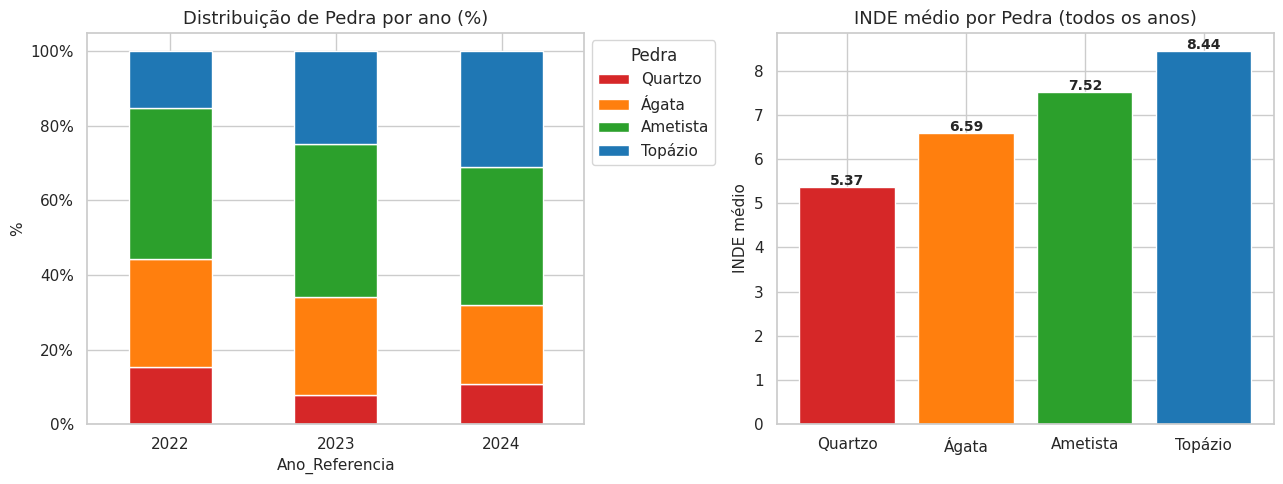

Qtd alunos por Pedra e Ano:
Pedra           Quartzo  Ágata  Ametista  Topázio
Ano_Referencia                                   
2022                132    250       348      130
2023                 72    246       381      232
2024                112    225       391      326


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribuição de Pedra por ano
pedra_ano = (df[df['Pedra'].isin(ORDEM_PEDRA)]
               .groupby(['Ano_Referencia','Pedra'])
               .size().unstack().reindex(columns=ORDEM_PEDRA))
pedra_pct = pedra_ano.div(pedra_ano.sum(axis=1), axis=0) * 100
pedra_pct.plot(kind='bar', ax=axes[0], stacked=True, rot=0,
               color=['#d62728','#ff7f0e','#2ca02c','#1f77b4'])
axes[0].set_title('Distribuição de Pedra por ano (%)')
axes[0].set_ylabel('%')
axes[0].legend(title='Pedra', bbox_to_anchor=(1,1))
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

# INDE médio por Pedra (mostra nível de cada classificação)
inde_med = df[df['Pedra'].isin(ORDEM_PEDRA)].groupby('Pedra')['INDE'].mean().reindex(ORDEM_PEDRA)
cores_pedra = ['#d62728','#ff7f0e','#2ca02c','#1f77b4']
axes[1].bar(inde_med.index, inde_med.values, color=cores_pedra)
axes[1].set_title('INDE médio por Pedra (todos os anos)')
axes[1].set_ylabel('INDE médio')
for i, v in enumerate(inde_med.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p10_efetividade.png', bbox_inches='tight')
plt.show()

print('Qtd alunos por Pedra e Ano:')
print(pedra_ano)


## Pergunta 11 — Insights e Criatividade
*Insights adicionais não abordados pelas perguntas anteriores.*


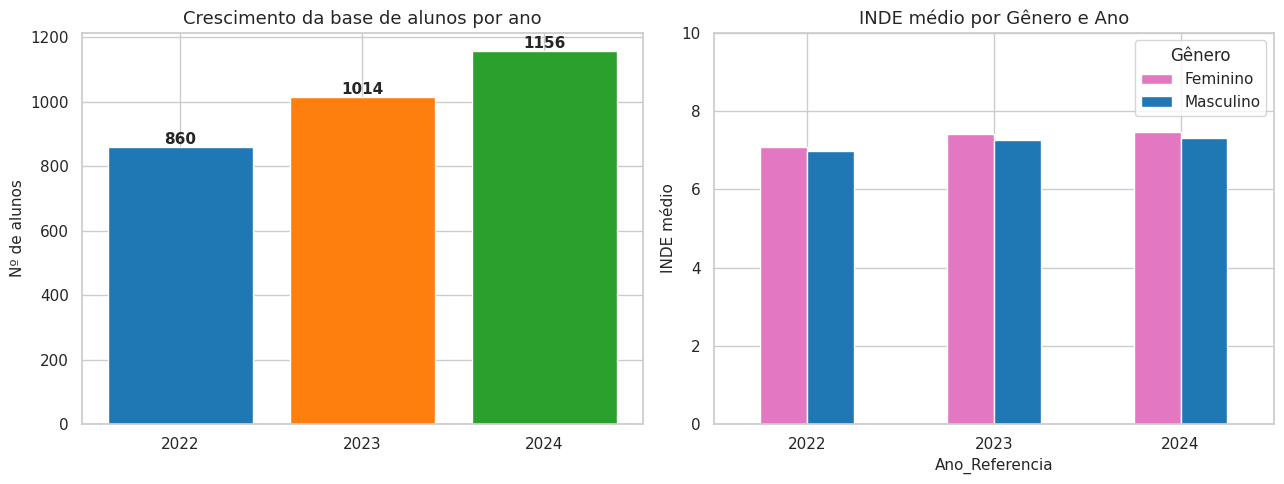

INDE médio por Gênero e Ano:
Genero_Std      Feminino  Masculino
Ano_Referencia                     
2022               7.090      6.975
2023               7.408      7.269
2024               7.476      7.304


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Insight 1: Crescimento da base ao longo dos anos
alunos_ano = df.groupby('Ano_Referencia')['RA'].nunique()
axes[0].bar(alunos_ano.index.astype(str), alunos_ano.values,
            color=['#1f77b4','#ff7f0e','#2ca02c'])
for i, v in enumerate(alunos_ano.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Crescimento da base de alunos por ano')
axes[0].set_ylabel('Nº de alunos')

# Insight 2: INDE médio por Gênero e Ano
genero_valido = ['Masculino','Feminino','Menino','Menina']
df_gen = df[df['Genero'].isin(genero_valido)].copy()
df_gen['Genero_Std'] = df_gen['Genero'].replace({'Menino':'Masculino','Menina':'Feminino'})
inde_gen = df_gen.groupby(['Ano_Referencia','Genero_Std'])['INDE'].mean().unstack()
inde_gen.plot(kind='bar', ax=axes[1], rot=0, color=['#e377c2','#1f77b4'])
axes[1].set_title('INDE médio por Gênero e Ano')
axes[1].set_ylabel('INDE médio')
axes[1].legend(title='Gênero')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p11_insights.png', bbox_inches='tight')
plt.show()

print('INDE médio por Gênero e Ano:')
print(inde_gen.round(3))


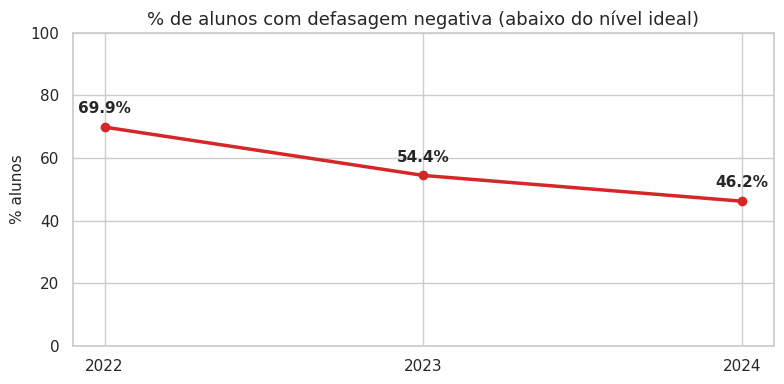

Ano_Referencia
2022    69.9
2023    54.4
2024    46.2
Name: % Defasagem negativa, dtype: float64


In [12]:
# Insight 3: Defasagem ao longo do tempo (% com defasagem < 0)
fig, ax = plt.subplots(figsize=(8, 4))
def_neg = df.groupby('Ano_Referencia').apply(
    lambda x: (x['Defasagem'] < 0).mean() * 100
)
ax.plot(def_neg.index, def_neg.values, marker='o', linewidth=2.5, color='#d62728')
for x, y in zip(def_neg.index, def_neg.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')
ax.set_title('% de alunos com defasagem negativa (abaixo do nível ideal)')
ax.set_ylabel('% alunos')
ax.set_xticks(ANOS)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/p11_defasagem.png', bbox_inches='tight')
plt.show()
print(def_neg.rename('% Defasagem negativa').round(1))


## Resumo dos Principais Achados

| # | Pergunta | Principal achado |
|---|---|---|
| 1 | IAN / Defasagem | Maioria dos alunos tem IAN adequado (10); proporção de adequados cresce de ~57% (2022) para ~63% (2024) |
| 2 | IDA | IDA médio oscila mas se mantém acima de 7; fases iniciais (ALFA, F1) têm IDA menor, crescendo nas fases avançadas |
| 3 | IEG | Correlação IEG×IDA ≈ 0.54 e IEG×IPV ≈ 0.56 — engajamento tem relação moderada-alta com desempenho e ponto de virada |
| 4 | IAA | IAA tem correlação fraca com IDA (r≈0.12) e IEG (r≈0.13) — alunos tendem a se autoavaliar bem independente do desempenho real |
| 5 | IPS | Alunos que caem em IDA no ano seguinte apresentam IPS ligeiramente inferior no ano anterior |
| 6 | IPP | IPP cai consistentemente entre alunos com IAN severo — confirmando a defasagem |
| 7 | IPV | IDA e IEG têm maior correlação com IPV; alunos que atingiram o PV em 2022 têm IDA e IEG médios superiores |
| 8 | INDE | IDA (r≈0.79) e IEG (r≈0.75) são os maiores drivers do INDE; IPS é o menos correlacionado (r≈0.20) |
| 10 | Efetividade | Topázio cresce de 15% (2022) para 28% (2024); Quartzo diminui — sinal positivo de evolução do programa |
| 11 | Insights | Base cresceu 34% entre 2022 e 2024; gênero não gera diferença significativa no INDE; defasagem negativa cai ao longo dos anos |
